# 📊 Guia Didático: PCA em Métricas Energéticas de Ciclones

## O que este notebook faz?

Este notebook é um **guia passo a passo** para aplicar **Análise de Componentes Principais (PCA)** em dados energéticos de ciclones extratropicais.

### 🎯 Objetivo
Reduzir a dimensionalidade dos dados energéticos de ciclones para:
1. Capturar os padrões dominantes em ~90-95% da variância
2. Preparar dados compactos para clusterização
3. Facilitar a interpretação física dos padrões energéticos

### 📥 Dados de entrada
- **Ciclones**: rastreados com 4 fases de vida (incipiente, intensificação, maturação, decaimento)
- **Variáveis**: ~7 termos energéticos (Ae, Ke, Ca, Ck, etc.) calculados para cada timestep
- **Formato inicial**: múltiplas linhas por ciclone (1 por timestep)

### 📤 Outputs finais
1. **`wide`** (n × 28): matriz com 1 linha por ciclone, colunas = termo×fase (ex: Ae_inc, Ae_int, ...)
2. **`X_scaled`** (n × 28): matriz `wide` padronizada (média 0, std 1)
3. **`df_pca`** (n × k): scores dos ciclones nos k componentes principais (**input para clustering**)
4. **`loadings_df`** (k × 28): pesos das 28 features em cada PC (**para interpretação**)
5. **Variância explicada**: escolha do número ótimo de componentes

---


## 1️⃣ Imports e Configurações

Aqui importamos as bibliotecas necessárias e definimos as constantes do projeto.


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configurar projeto
PROJECT_ROOT = Path(os.getcwd()).resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.utils.preprocess_data import load_cache, filter_complete_lifecycle_cyclones

warnings.filterwarnings('ignore')

# Configurar matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("✓ Imports realizados com sucesso")

✓ Imports realizados com sucesso


In [2]:
# === Variáveis energéticas (7 termos) ===
ENERGY_VARS = [
    'Ae',   # Available Potential Energy
    'Ke',   # Kinetic Energy
    'Ca',   # Conversion: Ae → Ke
    'Ck',   # Conversion: eddy → mean
    'BAe',  # Boundary flux Ae
    'BKe',  # Boundary flux Ke
    'Ge'    # Generation of Ae
]

# === Fases do ciclo de vida (ordem cronológica) ===
PHASE_ORDER = ['incipient', 'intensification', 'mature', 'decay']
PHASE_ABBR = {
    'incipient': 'inc',
    'intensification': 'int',
    'mature': 'mat',
    'decay': 'dec'
}

# === Configurações do PCA ===
VARIANCE_THRESHOLD = 0.90  # Manter PCs que explicam 90% da variância
RANDOM_STATE = 42          # Para reprodutibilidade

print(f"✓ Configurações definidas:")
print(f"  - {len(ENERGY_VARS)} termos energéticos × {len(PHASE_ORDER)} fases = {len(ENERGY_VARS) * len(PHASE_ORDER)} features")
print(f"  - Threshold de variância: {VARIANCE_THRESHOLD*100:.0f}%")

✓ Configurações definidas:
  - 7 termos energéticos × 4 fases = 28 features
  - Threshold de variância: 90%


## Funções Utilitárias

Para evitar repetição de código, criamos funções auxiliares para inspecionar DataFrames e arrays.


In [3]:
def report_df(df: pd.DataFrame, name: str) -> None:
    """Relata informações básicas de um DataFrame."""
    print(f"\n{'='*70}")
    print(f"📊 {name}")
    print(f"{'='*70}")
    print(f"Shape: {df.shape[0]} linhas × {df.shape[1]} colunas")
    print(f"Colunas: {list(df.columns[:5])}{'...' if len(df.columns) > 5 else ''}")
    print(f"Index: {df.index.name} (primeiros valores: {list(df.index[:3])})")
    
    # Checar NaNs
    n_nans = df.isna().sum().sum()
    if n_nans > 0:
        print(f"⚠️  NaNs encontrados: {n_nans} valores")
    else:
        print(f"✓ Sem NaNs")
    
    # Mostrar primeiras linhas
    print(f"\nPrimeiras 3 linhas:")
    print(df.head(3))


def report_array(X: np.ndarray, name: str, feature_names: list = None) -> None:
    """Relata informações básicas de um array numpy."""
    print(f"\n{'='*70}")
    print(f"🔢 {name}")
    print(f"{'='*70}")
    print(f"Shape: {X.shape}")
    print(f"Dtype: {X.dtype}")
    print(f"Estatísticas: min={X.min():.3f}, max={X.max():.3f}, mean={X.mean():.3f}, std={X.std():.3f}")
    
    # Checar NaNs
    n_nans = np.isnan(X).sum()
    if n_nans > 0:
        print(f"⚠️  NaNs encontrados: {n_nans} valores")
    else:
        print(f"✓ Sem NaNs")
    
    # Mostrar primeiros valores
    print(f"\nPrimeiras 3 linhas × primeiras 5 colunas:")
    print(X[:3, :min(5, X.shape[1])])


print("✓ Funções utilitárias definidas: report_df(), report_array()")

✓ Funções utilitárias definidas: report_df(), report_array()


## 2️⃣ Carregar Dados Brutos

Carregamos o cache de energia e fazemos uma primeira inspeção.

### O que esperamos:
- Múltiplas linhas por ciclone (1 por timestep)
- Colunas: track_id, phase, period, + 7 termos energéticos
- Milhares de registros


In [4]:
# Carregar cache
df_raw = load_cache()

print(f"✓ Cache carregado: {len(df_raw):,} registros")
print(f"✓ Número de ciclones únicos: {df_raw['track_id'].nunique()}")
print(f"✓ Colunas disponíveis: {list(df_raw.columns)}")

# Inspeção rápida
report_df(df_raw, "DataFrame bruto (df_raw)")

Loading cache from /Users/danilocoutodesouza/Documents/Programs_and_scripts/paper_energy_patterns/data/energy_cache.parquet...
✓ Loaded 25000 records from 6789 cyclones
✓ Cache carregado: 25,000 registros
✓ Número de ciclones únicos: 6789
✓ Colunas disponíveis: ['period', 'Az', 'Ae', 'Kz', 'Ke', 'Cz', 'Ca', 'Ck', 'Ce', 'BAz', 'BAe', 'BKz', 'BKe', 'BΦZ', 'BΦE', 'Gz', 'Ge', '∂Az/∂t (finite diff.)', '∂Ae/∂t (finite diff.)', '∂Kz/∂t (finite diff.)', '∂Ke/∂t (finite diff.)', 'RGz', 'RKz', 'RGe', 'RKe', 'track_id', 'phase']

📊 DataFrame bruto (df_raw)
Shape: 25000 linhas × 27 colunas
Colunas: ['period', 'Az', 'Ae', 'Kz', 'Ke']...
Index: None (primeiros valores: [0, 1, 2])
✓ Sem NaNs

Primeiras 3 linhas:
            period             Az             Ae            Kz             Ke  \
0            decay  222924.404092  122868.424155  2.604940e+06  330637.025696   
1            decay  265336.848429  176200.424990  1.243818e+06  365684.555894   
2  intensification  464331.935902   79935.401945  

### ✅ Outputs desta etapa

| Objeto | Shape | O que representa |
|--------|-------|------------------|
| `df_raw` | (N × M) | Dados brutos com múltiplas linhas por ciclone |


## 3️⃣ Filtrar Ciclones Completos

**Por que?** Para garantir comparação justa, mantemos apenas ciclones com **todas as 4 fases** na sequência correta.

### Critérios:
1. Ter as 4 fases: incipient → intensification → mature → decay
2. Sem NaNs nos 7 termos energéticos
3. Fases na ordem cronológica


In [5]:
# Filtrar apenas ciclones com ciclo de vida completo
df_complete = filter_complete_lifecycle_cyclones(df_raw)

print(f"\n{'='*70}")
print("Comparação antes/depois do filtro:")
print(f"{'='*70}")
print(f"Antes:  {df_raw['track_id'].nunique()} ciclones, {len(df_raw):,} registros")
print(f"Depois: {df_complete['track_id'].nunique()} ciclones, {len(df_complete):,} registros")
print(f"Perda:  {df_raw['track_id'].nunique() - df_complete['track_id'].nunique()} ciclones ({(1 - df_complete['track_id'].nunique()/df_raw['track_id'].nunique())*100:.1f}%)")

# Distribuição de fases
print(f"\nDistribuição por fase (ciclones completos):")
for phase in PHASE_ORDER:
    count = (df_complete['phase'] == phase).sum()
    print(f"  {phase:20s}: {count:6,} registros")


Filtering complete lifecycle cyclones
Input: 6789 cyclones, 25000 records

✓ Found 3820 complete lifecycle cyclones
  (56.3% of total)

✓ Filtered dataset: 15829 records from 3820 cyclones

Phase distribution in complete cyclones:
  incipient           :   3820 records (24.1%)
  intensification     :   4003 records (25.3%)
  mature              :   4003 records (25.3%)
  decay               :   4003 records (25.3%)


Comparação antes/depois do filtro:
Antes:  6789 ciclones, 25,000 registros
Depois: 3820 ciclones, 15,829 registros
Perda:  2969 ciclones (43.7%)

Distribuição por fase (ciclones completos):
  incipient           :  3,820 registros
  intensification     :  4,003 registros
  mature              :  4,003 registros
  decay               :  4,003 registros


### Remover NaNs nos termos energéticos


In [6]:
# Converter para numérico e remover NaNs
for var in ENERGY_VARS:
    df_complete[var] = pd.to_numeric(df_complete[var], errors='coerce')

df_clean = df_complete.dropna(subset=ENERGY_VARS).copy()

n_dropped = len(df_complete) - len(df_clean)
if n_dropped > 0:
    print(f"⚠️  Removidos {n_dropped:,} registros com NaNs ({n_dropped/len(df_complete)*100:.1f}%)")
else:
    print(f"✓ Sem NaNs nos termos energéticos")

print(f"\n✓ Dataset limpo: {len(df_clean):,} registros, {df_clean['track_id'].nunique()} ciclones")

# Inspeção
report_df(df_clean[['track_id', 'phase', 'period'] + ENERGY_VARS], "df_clean (primeiras colunas)")

✓ Sem NaNs nos termos energéticos

✓ Dataset limpo: 15,829 registros, 3820 ciclones

📊 df_clean (primeiras colunas)
Shape: 15829 linhas × 10 colunas
Colunas: ['track_id', 'phase', 'period', 'Ae', 'Ke']...
Index: None (primeiros valores: [3, 4, 5])
✓ Sem NaNs

Primeiras 3 linhas:
   track_id            phase           period             Ae             Ke  \
3  19790455        incipient        incipient  170020.987759  172025.282609   
4  19790455  intensification  intensification  118577.214009  214968.586229   
5  19790455           mature           mature   81170.598715  144566.250110   

         Ca        Ck       BAe       BKe        Ge  
3 -0.130528 -0.097042  5.373906 -8.731883 -0.996327  
4  0.818833 -1.994650  0.507888  0.008781  1.566363  
5 -0.169235  5.950016  2.519393  3.420159 -1.724267  


### 📊 Visualização: Distribuição de 2 termos energéticos (exemplo)


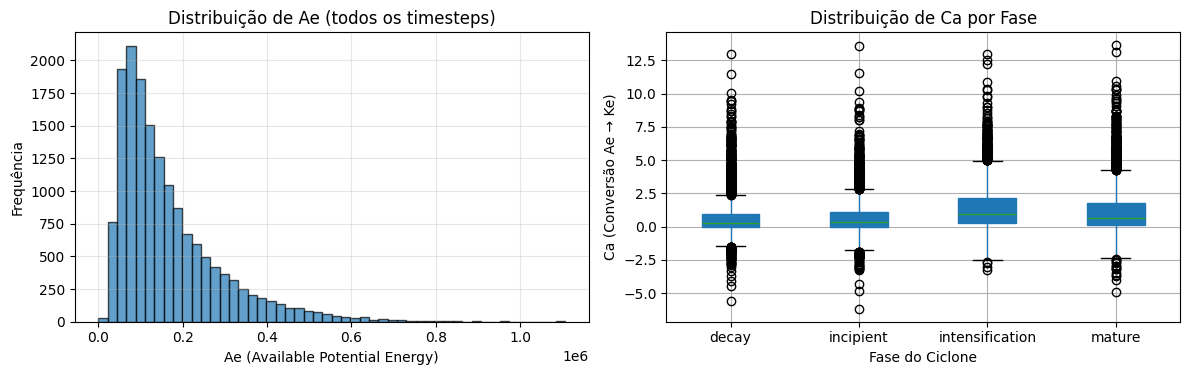

✓ Visualizações geradas


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de Ae
axes[0].hist(df_clean['Ae'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Ae (Available Potential Energy)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de Ae (todos os timesteps)')
axes[0].grid(True, alpha=0.3)

# Boxplot de Ca por fase
df_clean.boxplot(column='Ca', by='phase', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('Fase do Ciclone')
axes[1].set_ylabel('Ca (Conversão Ae → Ke)')
axes[1].set_title('Distribuição de Ca por Fase')
axes[1].get_figure().suptitle('')  # Remove título automático
plt.tight_layout()
plt.show()

print("✓ Visualizações geradas")

### ✅ Outputs desta etapa

| Objeto | Shape | O que representa |
|--------|-------|------------------|
| `df_clean` | (N × M) | Apenas ciclones completos (4 fases), sem NaNs |

**Próximo passo:** agregar por ciclone e fase (calcular médias).


## 4️⃣ Agregar por Ciclone e Fase

**Por que?** Cada ciclone tem múltiplos timesteps por fase. Queremos **1 valor por ciclone-fase** (a média).

### Transformação:
- **Antes**: milhares de linhas (1 por timestep)
- **Depois**: n_ciclones × 4 linhas (1 por fase)


In [8]:
# Agregar: média dos termos energéticos por (ciclone, fase)
agg = (
    df_clean
    .groupby(['track_id', 'phase'])[ENERGY_VARS]
    .mean()
    .reset_index()
)

print(f"✓ Agregação concluída:")
print(f"  - {len(agg):,} linhas (deveria ser ~{df_clean['track_id'].nunique() * 4})")
print(f"  - {df_clean['track_id'].nunique()} ciclones × 4 fases")

# Verificar se todos os ciclones têm 4 fases
phase_counts_per_cyclone = agg.groupby('track_id').size()
if (phase_counts_per_cyclone == 4).all():
    print(f"✓ Todos os {len(phase_counts_per_cyclone)} ciclones têm exatamente 4 fases")
else:
    print(f"⚠️  Alguns ciclones não têm 4 fases!")
    print(phase_counts_per_cyclone.value_counts())

report_df(agg, "agg (dados agregados)")

✓ Agregação concluída:
  - 15,280 linhas (deveria ser ~15280)
  - 3820 ciclones × 4 fases
✓ Todos os 3820 ciclones têm exatamente 4 fases

📊 agg (dados agregados)
Shape: 15280 linhas × 9 colunas
Colunas: ['track_id', 'phase', 'Ae', 'Ke', 'Ca']...
Index: None (primeiros valores: [0, 1, 2])
✓ Sem NaNs

Primeiras 3 linhas:
   track_id            phase             Ae             Ke        Ca  \
0  19790001            decay   17371.223228   91180.653078  0.095466   
1  19790001        incipient  226938.667027  397670.079023  3.004067   
2  19790001  intensification  220847.684617  317241.623101  0.284463   

         Ck        BAe       BKe        Ge  
0 -1.065316  -0.411262  0.598055  0.129856  
1 -3.197251   2.445937  8.321027  8.754446  
2  0.660114  11.130850 -7.407092  1.828975  


### ✅ Outputs desta etapa

| Objeto | Shape | O que representa |
|--------|-------|------------------|
| `agg` | (n×4) × (7+2) | Média dos 7 termos por ciclone-fase (formato long) |

**Colunas:** track_id, phase, Ae, Ke, Ca, Ck, BAe, BKe, Ge


## 5️⃣ Pivotear para Formato Wide

**Transformação crucial!** Convertemos de "long" para "wide":
- **Long (atual)**: 1 linha por (ciclone, fase) → n×4 linhas
- **Wide (desejado)**: 1 linha por ciclone → n linhas, com colunas termo_fase

### Exemplo:
```
Long:                          Wide:
track_id  phase   Ae  Ke       track_id  Ae_inc  Ae_int  ...  Ke_dec
1         inc     10  20  →    1         10      15      ...  30
1         int     15  25
...
```


In [9]:
# Pivot: transformar fases em colunas
wide = agg.pivot(index='track_id', columns='phase', values=ENERGY_VARS)

# Garantir ordem consistente: termo × fase
full_cols = pd.MultiIndex.from_product([ENERGY_VARS, PHASE_ORDER])
wide = wide.reindex(columns=full_cols)

# Achatar nomes de coluna: termo_fase_abrev (ex: Ae_inc, Ae_int, ...)
wide.columns = [f"{var}_{PHASE_ABBR[phase]}" for var, phase in wide.columns]

# Ordenar colunas para consistência
ordered_cols = [f"{var}_{PHASE_ABBR[phase]}" for var in ENERGY_VARS for phase in PHASE_ORDER]
wide = wide[ordered_cols]

print(f"✓ Matriz wide criada: {wide.shape[0]} ciclones × {wide.shape[1]} features (termo×fase)")
print(f"✓ Primeiras colunas: {list(wide.columns[:8])}")
print(f"✓ Últimas colunas: {list(wide.columns[-4:])}")

# Verificar NaNs
n_nans = wide.isna().sum().sum()
if n_nans > 0:
    print(f"\n⚠️  {n_nans} NaNs encontrados na matriz wide")
    print("Colunas com NaNs:")
    nan_cols = wide.columns[wide.isna().any()]
    for col in nan_cols:
        n = wide[col].isna().sum()
        print(f"  {col}: {n} NaNs")
    
    # Remover ciclones com NaNs
    wide = wide.dropna()
    print(f"\n✓ Removidos ciclones com NaNs. Nova shape: {wide.shape}")
else:
    print(f"✓ Sem NaNs na matriz wide")

report_df(wide, "wide (matriz termo×fase)")

✓ Matriz wide criada: 3820 ciclones × 28 features (termo×fase)
✓ Primeiras colunas: ['Ae_inc', 'Ae_int', 'Ae_mat', 'Ae_dec', 'Ke_inc', 'Ke_int', 'Ke_mat', 'Ke_dec']
✓ Últimas colunas: ['Ge_inc', 'Ge_int', 'Ge_mat', 'Ge_dec']
✓ Sem NaNs na matriz wide

📊 wide (matriz termo×fase)
Shape: 3820 linhas × 28 colunas
Colunas: ['Ae_inc', 'Ae_int', 'Ae_mat', 'Ae_dec', 'Ke_inc']...
Index: track_id (primeiros valores: [19790001, 19790026, 19790048])
✓ Sem NaNs

Primeiras 3 linhas:
                 Ae_inc         Ae_int         Ae_mat        Ae_dec  \
track_id                                                              
19790001  226938.667027  220847.684617   47218.608810  17371.223228   
19790026  321596.411219  153216.411603   33570.311436  39652.030633   
19790048  280881.036081  395447.095089  162463.056697  36064.466363   

                 Ke_inc         Ke_int         Ke_mat         Ke_dec  \
track_id                                                               
19790001  397670.079023  3

### 📊 Visualização: Correlação entre features

Vamos ver quais features (termo×fase) são correlacionadas. Isso nos dá intuição sobre redundância nos dados.


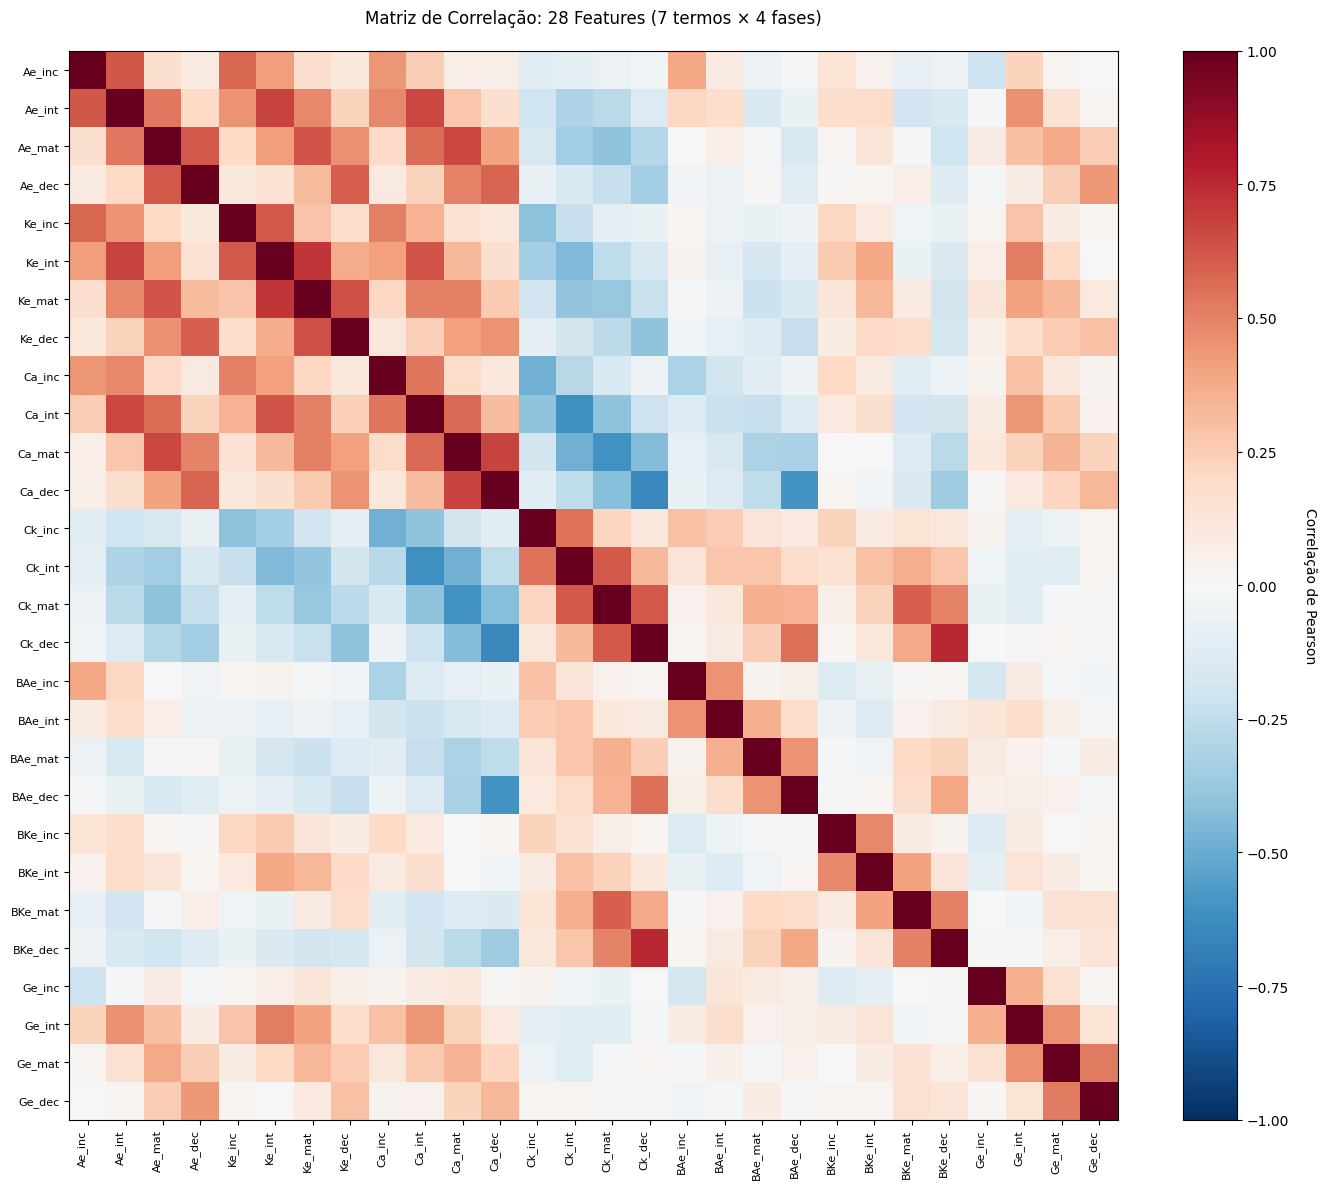

✓ Heatmap de correlação gerado

Algumas correlações fortes (|r| > 0.7):
Ck_dec  BKe_dec    0.751148
Ke_int  Ke_mat     0.713768
dtype: float64


In [10]:
# Calcular matriz de correlação
corr_matrix = wide.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Configurar eixos
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, ha='right', fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlação de Pearson', rotation=270, labelpad=20)

ax.set_title('Matriz de Correlação: 28 Features (7 termos × 4 fases)', pad=20)
plt.tight_layout()
plt.show()

print("✓ Heatmap de correlação gerado")
print(f"\nAlgumas correlações fortes (|r| > 0.7):")
# Pegar triângulo superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_upper = corr_matrix.where(mask)
strong_corr = corr_upper[(corr_upper.abs() > 0.7)].stack().sort_values(ascending=False)
print(strong_corr.head(10))

### ✅ Outputs desta etapa

| Objeto | Shape | O que representa |
|--------|-------|------------------|
| `wide` | (n × 28) | **Matriz de assinatura energética**: 1 linha/ciclone, colunas = termo×fase |

**Colunas:** Ae_inc, Ae_int, Ae_mat, Ae_dec, Ke_inc, ..., Ge_dec (total: 7×4=28)

**Interpretação:** cada linha é o "perfil energético" completo de 1 ciclone ao longo das 4 fases.


## 6️⃣ Padronização (Standardization)

**Por que?** PCA é sensível à escala. Termos com magnitudes maiores dominariam os PCs.

### O que fazemos:
- **StandardScaler**: transforma cada coluna para média=0, std=1
- Fórmula: `z = (x - μ) / σ`

### Resultado:
- Todas as 28 features ficam na mesma escala
- PCA pode identificar padrões de **variância relativa**, não absoluta


In [11]:
# Extrair matriz numpy e nomes
X = wide.to_numpy(dtype=float)
feature_names = wide.columns.to_list()
cyclone_ids = wide.index.to_numpy()

print(f"✓ Matriz X extraída: {X.shape}")

# Padronizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✓ Padronização aplicada")
print(f"\nVerificação (média ≈ 0, std ≈ 1):")
for i in [0, 3, 10]:  # Checar 3 colunas como exemplo
    print(f"  {feature_names[i]:12s}: mean={X_scaled[:, i].mean():7.4f}, std={X_scaled[:, i].std():7.4f}")

# Reportar array
report_array(X_scaled, "X_scaled (matriz padronizada)", feature_names)

# Salvar dados escalados em DataFrame (opcional, para inspeção)
df_scaled = pd.DataFrame(
    X_scaled,
    index=wide.index,
    columns=[f"{col}_scaled" for col in feature_names]
)
print(f"\n✓ DataFrame com dados escalados criado: {df_scaled.shape}")

✓ Matriz X extraída: (3820, 28)
✓ Padronização aplicada

Verificação (média ≈ 0, std ≈ 1):
  Ae_inc      : mean=-0.0000, std= 1.0000
  Ae_dec      : mean= 0.0000, std= 1.0000
  Ca_mat      : mean= 0.0000, std= 1.0000

🔢 X_scaled (matriz padronizada)
Shape: (3820, 28)
Dtype: float64
Estatísticas: min=-14.653, max=9.287, mean=-0.000, std=1.000
✓ Sem NaNs

Primeiras 3 linhas × primeiras 5 colunas:
[[ 0.38279192  0.14535402 -0.95222652 -1.14002907  0.70151451]
 [ 1.12090796 -0.37389813 -1.06381631 -0.90136216  0.0827374 ]
 [ 0.80342024  1.4858747  -0.00997686 -0.93979133 -0.32545283]]

✓ DataFrame com dados escalados criado: (3820, 28)


### ✅ Outputs desta etapa

| Objeto | Shape | O que representa |
|--------|-------|------------------|
| `X` | (n × 28) | Matriz wide como numpy array (valores originais) |
| `X_scaled` | (n × 28) | Matriz padronizada (média=0, std=1 por coluna) |
| `scaler` | objeto | StandardScaler ajustado (pode reverter a transformação) |


## 7️⃣ Aplicar PCA (Principal Component Analysis)

### O que é PCA?
- Rotação dos eixos para encontrar **direções de máxima variância**
- 1º PC: direção com maior variância
- 2º PC: 2ª maior variância (ortogonal ao 1º)
- ...e assim por diante

### Estratégia:
1. Rodar PCA com **todos os componentes** para ver variância explicada
2. Decidir quantos PCs manter (threshold: 90% de variância)
3. Re-aplicar PCA com número escolhido de componentes


In [12]:
# Passo 1: PCA completo (todos os componentes)
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

# Variância explicada por cada PC
explained_var = pca_full.explained_variance_ratio_
cumsum_var = np.cumsum(explained_var)

print(f"✓ PCA completo ajustado ({len(explained_var)} componentes)")
print(f"\nVariância explicada pelos primeiros 10 PCs:")
for i in range(min(10, len(explained_var))):
    print(f"  PC{i+1:2d}: {explained_var[i]*100:5.2f}%  (acumulado: {cumsum_var[i]*100:5.2f}%)")

# Determinar número de componentes para manter
n_keep = np.argmax(cumsum_var >= VARIANCE_THRESHOLD) + 1
print(f"\n✓ Para {VARIANCE_THRESHOLD*100:.0f}% de variância: manter {n_keep} componentes")
print(f"  Variância explicada: {cumsum_var[n_keep-1]*100:.2f}%")

# Passo 2: Re-aplicar PCA com número escolhido
pca = PCA(n_components=n_keep, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"\n✓ PCA final aplicado:")
print(f"  Input: {X_scaled.shape}")
print(f"  Output: {X_pca.shape}")
print(f"  Redução de dimensionalidade: {X_scaled.shape[1]} → {X_pca.shape[1]} ({X_pca.shape[1]/X_scaled.shape[1]*100:.1f}%)")

report_array(X_pca, f"X_pca (scores nos {n_keep} PCs)")

✓ PCA completo ajustado (28 componentes)

Variância explicada pelos primeiros 10 PCs:
  PC 1: 24.86%  (acumulado: 24.86%)
  PC 2: 12.18%  (acumulado: 37.04%)
  PC 3:  9.63%  (acumulado: 46.66%)
  PC 4:  7.34%  (acumulado: 54.00%)
  PC 5:  6.80%  (acumulado: 60.81%)
  PC 6:  5.15%  (acumulado: 65.96%)
  PC 7:  4.26%  (acumulado: 70.22%)
  PC 8:  3.87%  (acumulado: 74.09%)
  PC 9:  3.59%  (acumulado: 77.68%)
  PC10:  2.76%  (acumulado: 80.44%)

✓ Para 90% de variância: manter 15 componentes
  Variância explicada: 90.28%

✓ PCA final aplicado:
  Input: (3820, 28)
  Output: (3820, 15)
  Redução de dimensionalidade: 28 → 15 (53.6%)

🔢 X_pca (scores nos 15 PCs)
Shape: (3820, 15)
Dtype: float64
Estatísticas: min=-11.828, max=21.163, mean=-0.000, std=1.298
✓ Sem NaNs

Primeiras 3 linhas × primeiras 5 colunas:
[[-1.46538557  0.48814958 -1.74548975  1.13815953 -0.86147727]
 [-1.31029988  0.72027732 -1.0771469  -0.54732439  1.21608185]
 [ 2.0084967   0.18337184 -2.0779553   0.85270785  0.86746322

### 📊 Visualização: Variância Explicada


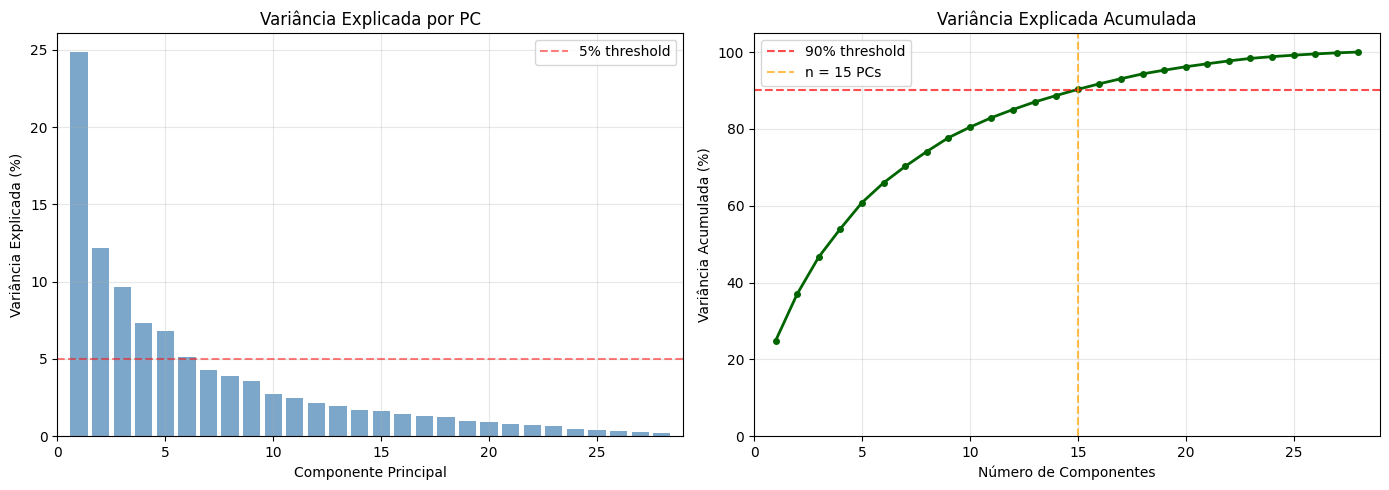

✓ Gráficos de variância explicada gerados


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Variância individual por PC
axes[0].bar(range(1, len(explained_var)+1), explained_var * 100, alpha=0.7, color='steelblue')
axes[0].axhline(y=5, color='red', linestyle='--', alpha=0.5, label='5% threshold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada (%)')
axes[0].set_title('Variância Explicada por PC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, min(len(explained_var)+1, 29))

# Plot 2: Variância acumulada
axes[1].plot(range(1, len(cumsum_var)+1), cumsum_var * 100, marker='o', markersize=4, linewidth=2, color='darkgreen')
axes[1].axhline(y=VARIANCE_THRESHOLD*100, color='red', linestyle='--', alpha=0.7, label=f'{VARIANCE_THRESHOLD*100:.0f}% threshold')
axes[1].axvline(x=n_keep, color='orange', linestyle='--', alpha=0.7, label=f'n = {n_keep} PCs')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Acumulada (%)')
axes[1].set_title('Variância Explicada Acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, min(len(cumsum_var)+1, 29))
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

print(f"✓ Gráficos de variância explicada gerados")

### ✅ Outputs desta etapa

| Objeto | Shape | O que representa |
|--------|-------|------------------|
| `pca` | objeto | Modelo PCA ajustado (sklearn) |
| `X_pca` | (n × k) | **Scores**: posição de cada ciclone nos k PCs |
| `explained_var` | (k,) | % de variância explicada por cada PC |
| `cumsum_var` | (k,) | % de variância acumulada |

**k** = número de PCs mantidos (ex: 8-12 para 90% de variância)


## 8️⃣ Resultados do PCA: Scores e Loadings

### Dois outputs principais:

#### 1. **Scores** (X_pca): onde cada ciclone está no espaço dos PCs
- Shape: (n ciclones × k PCs)
- **Uso**: input para clustering, visualização

#### 2. **Loadings** (pca.components_): peso de cada feature original em cada PC
- Shape: (k PCs × 28 features)
- **Uso**: interpretação física (quais termos energéticos dominam cada PC)


In [14]:
# === 1. DataFrame com scores (para clustering) ===
pc_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(
    X_pca,
    index=wide.index,  # track_id como índice
    columns=pc_columns
)

print(f"✓ df_pca criado: {df_pca.shape}")
report_df(df_pca, "df_pca (scores dos ciclones nos PCs)")

# === 2. DataFrame com loadings (para interpretação) ===
loadings_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,  # As 28 features originais
    index=pc_columns        # Os k PCs
)

print(f"\n✓ loadings_df criado: {loadings_df.shape}")
report_df(loadings_df, "loadings_df (pesos das features em cada PC)")

✓ df_pca criado: (3820, 15)

📊 df_pca (scores dos ciclones nos PCs)
Shape: 3820 linhas × 15 colunas
Colunas: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']...
Index: track_id (primeiros valores: [19790001, 19790026, 19790048])
✓ Sem NaNs

Primeiras 3 linhas:
               PC1       PC2       PC3       PC4       PC5       PC6  \
track_id                                                               
19790001 -1.465386  0.488150 -1.745490  1.138160 -0.861477  0.408786   
19790026 -1.310300  0.720277 -1.077147 -0.547324  1.216082  0.254578   
19790048  2.008497  0.183372 -2.077955  0.852708  0.867463  1.568265   

               PC7       PC8       PC9      PC10      PC11      PC12  \
track_id                                                               
19790001  2.428573 -0.179820 -1.153179 -1.492003  0.810297  0.863901   
19790026  0.653317 -0.661678 -0.118225  0.045424  0.217014 -0.593738   
19790048 -0.925954 -1.066376  1.192999  0.290638 -0.232384 -0.673360   

              PC13      PC14  

### 📊 Visualização: Scatter PC1 vs PC2

Visualiza a distribuição dos ciclones no espaço reduzido (sem labels de cluster ainda).


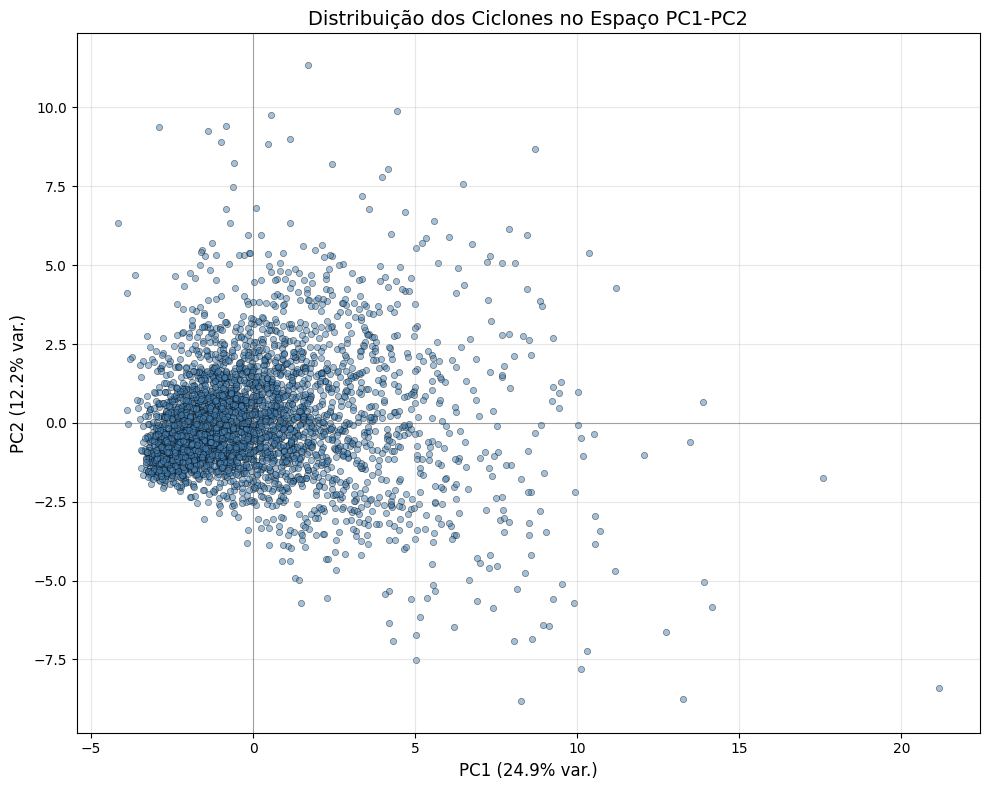

✓ Scatter PC1-PC2 gerado (3820 ciclones)


In [15]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.5, s=20, c='steelblue', edgecolors='k', linewidths=0.5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)', fontsize=12)
ax.set_title('Distribuição dos Ciclones no Espaço PC1-PC2', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Scatter PC1-PC2 gerado ({len(df_pca)} ciclones)")

### 📋 Top Loadings por PC

Para cada PC, mostramos as 5 features com maior |loading| (em valor absoluto).


In [16]:
print(f"\n{'='*70}")
print(f"Top 5 Features por PC (maior |loading|)")
print(f"{'='*70}\n")

for pc_name in pc_columns[:min(5, len(pc_columns))]:  # Primeiros 5 PCs
    loadings = loadings_df.loc[pc_name]
    top5 = loadings.abs().sort_values(ascending=False).head(5)
    
    print(f"{pc_name} ({pca.explained_variance_ratio_[int(pc_name[2:])-1]*100:.2f}% var.):")
    for feat, abs_val in top5.items():
        actual_val = loadings[feat]
        sign = '+' if actual_val > 0 else ''
        print(f"  {feat:12s}: {sign}{actual_val:7.4f}  (|{abs_val:.4f}|)")
    print()


Top 5 Features por PC (maior |loading|)

PC1 (24.86% var.):
  Ca_int      : + 0.2925  (|0.2925|)
  Ca_mat      : + 0.2857  (|0.2857|)
  Ke_mat      : + 0.2736  (|0.2736|)
  Ae_mat      : + 0.2726  (|0.2726|)
  Ke_int      : + 0.2701  (|0.2701|)

PC2 (12.18% var.):
  Ck_dec      : + 0.3223  (|0.3223|)
  BKe_dec     : + 0.2905  (|0.2905|)
  BKe_int     : + 0.2717  (|0.2717|)
  Ck_mat      : + 0.2696  (|0.2696|)
  BKe_mat     : + 0.2692  (|0.2692|)

PC3 (9.63% var.):
  Ge_dec      : + 0.3590  (|0.3590|)
  Ae_dec      : + 0.3450  (|0.3450|)
  Ke_dec      : + 0.2869  (|0.2869|)
  BKe_mat     : + 0.2862  (|0.2862|)
  Ge_mat      : + 0.2682  (|0.2682|)

PC4 (7.34% var.):
  BAe_inc     : + 0.5486  (|0.5486|)
  BAe_int     : + 0.5026  (|0.5026|)
  Ae_inc      : + 0.2750  (|0.2750|)
  Ck_inc      : + 0.2490  (|0.2490|)
  Ae_int      : + 0.2278  (|0.2278|)

PC5 (6.80% var.):
  BKe_inc     : + 0.4030  (|0.4030|)
  BKe_int     : + 0.3843  (|0.3843|)
  Ge_inc      : -0.3590  (|0.3590|)
  BAe_dec   

### 📊 Visualização: Heatmap dos Loadings


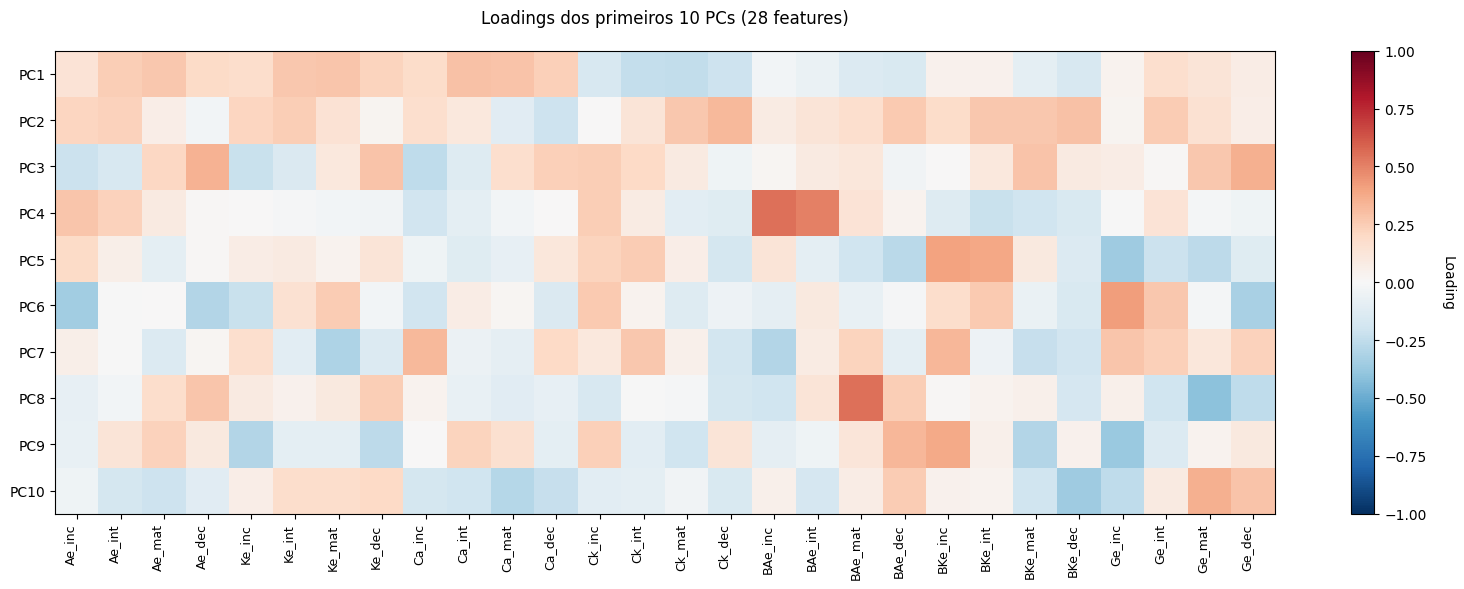

✓ Heatmap de loadings gerado


In [17]:
# Selecionar primeiros k PCs para visualizar (máx 10)
n_pcs_plot = min(10, loadings_df.shape[0])
loadings_subset = loadings_df.iloc[:n_pcs_plot]

fig, ax = plt.subplots(figsize=(16, 6))

im = ax.imshow(loadings_subset, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

# Eixos
ax.set_xticks(np.arange(len(feature_names)))
ax.set_yticks(np.arange(n_pcs_plot))
ax.set_xticklabels(feature_names, rotation=90, ha='right', fontsize=9)
ax.set_yticklabels([f'PC{i+1}' for i in range(n_pcs_plot)], fontsize=10)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Loading', rotation=270, labelpad=20)

ax.set_title(f'Loadings dos primeiros {n_pcs_plot} PCs (28 features)', pad=20)
plt.tight_layout()
plt.show()

print(f"✓ Heatmap de loadings gerado")

### ✅ Outputs desta etapa

| Objeto | Shape | O que representa |
|--------|-------|------------------|
| `df_pca` | (n × k) | **Scores**: coordenadas dos ciclones nos k PCs (input para clustering) |
| `loadings_df` | (k × 28) | **Loadings**: contribuição de cada feature original em cada PC |

**Como interpretar loadings:**
- **Magnitude**: quanto a feature contribui para o PC
- **Sinal**: direção da contribuição (+ ou -)
- Exemplo: se PC1 tem loading alto (+) em Ae_mat e (-) em Ca_dec, ciclones com PC1 alto têm muita energia Ae na maturação e pouca conversão Ca no decaimento


## 9️⃣ Interpretação Guiada

### Diferença entre Scores e Loadings

#### **Scores (df_pca)**
- **O que são**: coordenadas de cada ciclone no espaço dos PCs
- **Interpretação**: "onde o ciclone está"
- **Uso**: clustering, visualização, comparação entre ciclones
- Exemplo: Ciclone A tem PC1=2.5, PC2=-1.3

#### **Loadings (loadings_df)**
- **O que são**: pesos das features originais em cada PC
- **Interpretação**: "o que cada PC significa fisicamente"
- **Uso**: entender quais termos energéticos (e em quais fases) caracterizam cada PC
- Exemplo: PC1 tem loading alto em Ae_mat (+0.45) e Ca_int (+0.38)

### Como ler sinais e magnitudes

#### Magnitude do loading:
- **Alto (>0.3)**: feature contribui muito para o PC
- **Baixo (<0.1)**: feature contribui pouco

#### Sinal do loading:
- **Positivo (+)**: ciclones com score alto no PC tendem a ter valores altos nessa feature
- **Negativo (-)**: ciclones com score alto no PC tendem a ter valores baixos nessa feature

### Exemplo de interpretação:

Suponha:
- **PC1** tem loadings altos em: Ae_mat (+0.5), Ke_mat (+0.4), Ca_int (+0.3)
- **Ciclone X** tem score PC1 = 3.0 (alto)

**Interpretação física:**
Ciclone X é caracterizado por **alta energia potencial e cinética na fase madura**, e **forte conversão Az→Ae durante a intensificação**. É um ciclone "energeticamente intenso".

In [18]:
# Exemplo prático: analisar um ciclone específico
exemplo_cyclone_id = df_pca.index[0]
exemplo_scores = df_pca.loc[exemplo_cyclone_id]

print(f"{'='*70}")
print(f"Exemplo: Ciclone {exemplo_cyclone_id}")
print(f"{'='*70}\n")

print("Scores nos 5 primeiros PCs:")
for pc in pc_columns[:5]:
    score = exemplo_scores[pc]
    print(f"  {pc}: {score:7.3f}")

print(f"\nInterpretação baseada em PC1 (score = {exemplo_scores['PC1']:.3f}):")
pc1_loadings = loadings_df.loc['PC1'].abs().sort_values(ascending=False).head(3)
for feat in pc1_loadings.index:
    loading = loadings_df.loc['PC1', feat]
    original_value = wide.loc[exemplo_cyclone_id, feat]
    sign = "alto" if loading > 0 else "baixo"
    print(f"  - {feat}: loading={loading:+.3f} → espera-se valor {sign} (real: {original_value:.2f})")

print(f"\n💡 Conclusão: Este ciclone tem características {'fortes' if abs(exemplo_scores['PC1']) > 1 else 'moderadas'} no padrão PC1")

Exemplo: Ciclone 19790001

Scores nos 5 primeiros PCs:
  PC1:  -1.465
  PC2:   0.488
  PC3:  -1.745
  PC4:   1.138
  PC5:  -0.861

Interpretação baseada em PC1 (score = -1.465):
  - Ca_int: loading=+0.293 → espera-se valor alto (real: 0.28)
  - Ca_mat: loading=+0.286 → espera-se valor alto (real: 0.15)
  - Ke_mat: loading=+0.274 → espera-se valor alto (real: 136631.28)

💡 Conclusão: Este ciclone tem características fortes no padrão PC1


## 🔟 Próximos Passos

### 1️⃣ Clustering
Agora que temos os dados em espaço reduzido (`df_pca`), podemos aplicar algoritmos de clustering:
- **K-means**: encontrar grupos de ciclones com padrões energéticos similares
- **DBSCAN**: identificar clusters de densidade
- **Hierarchical**: criar dendrograma de similaridade

**Input para clustering**: `df_pca` (ou `X_pca`)

### 2️⃣ Interpretação dos Clusters
Depois de identificar clusters, voltamos às variáveis originais:
1. Para cada cluster, calcular **médias** das 28 features originais (termo×fase)
2. Comparar médias entre clusters
3. Identificar quais termos energéticos e fases distinguem os clusters

### 3️⃣ Análise Física
Com os clusters interpretados, podemos:
- Relacionar com características sinóticas (latitude, estação, intensidade)
- Estudar padrões temporais (ciclo de vida)
- Validar com casos individuais

---

### ⚠️ Nota Importante: "Somar Médias de Volta"

**Não é possível reverter scores de volta para valores originais exatos!**

- PCA é uma **projeção**: perdemos informação (componentes menores)
- Mas podemos:
  - Calcular médias das features originais **por cluster** para interpretação
  - Usar `pca.inverse_transform(X_pca)` para aproximar valores originais (com perda)

**Para interpretação física**: sempre voltar ao `wide` (matriz original) e calcular estatísticas por grupo.

---

## 📌 Resumo dos Principais Outputs

### Tabela Resumo

| Objeto | Tipo | Shape | Descrição | Uso Principal |
|--------|------|-------|-----------|---------------|
| **`df_raw`** | DataFrame | (N × M) | Dados brutos (múltiplas linhas/ciclone) | Input inicial |
| **`df_clean`** | DataFrame | (N × M) | Dados limpos (só ciclones completos, sem NaNs) | Após filtros |
| **`agg`** | DataFrame | (n×4 × 9) | Agregado por (ciclone, fase): médias dos 7 termos | Formato long |
| **`wide`** | DataFrame | (n × 28) | **Assinatura energética**: 1 linha/ciclone, colunas = termo×fase | Matriz PCA input |
| **`X`** | ndarray | (n × 28) | `wide` como numpy array | Forma matricial |
| **`X_scaled`** | ndarray | (n × 28) | Matriz padronizada (μ=0, σ=1) | Input do PCA |
| **`pca`** | PCA | - | Modelo PCA ajustado (sklearn) | Transformar novos dados |
| **`X_pca`** | ndarray | (n × k) | Scores: posição dos ciclones nos k PCs | Forma matricial |
| **`df_pca`** | DataFrame | (n × k) | **Scores** com track_id | **→ INPUT CLUSTERING** |
| **`loadings_df`** | DataFrame | (k × 28) | **Loadings**: pesos das features em cada PC | **→ INTERPRETAÇÃO** |

---

### Valores típicos

- **n**: número de ciclones (~500-2000)
- **k**: número de PCs mantidos (~8-15 para 90-95% variância)
- **28**: 7 termos energéticos × 4 fases

---

### Fluxo de trabalho completo

```
df_raw (milhares de linhas)
    ↓ [filtrar + limpar]
df_clean (ciclones completos)
    ↓ [agregar por ciclone-fase]
agg (n×4 linhas)
    ↓ [pivot]
wide (n × 28)
    ↓ [padronizar]
X_scaled (n × 28)
    ↓ [PCA]
df_pca (n × k)  ←── INPUT PARA CLUSTERING
    ↓
[K-means, DBSCAN, etc.]
    ↓
Clusters + interpretação via loadings_df
```

---

### 🎯 Principais outputs para as próximas etapas

1. **Para clustering**: `df_pca` (scores nos PCs)
2. **Para interpretação física**: `loadings_df` (quais features dominam cada PC)
3. **Para voltar aos valores originais**: `wide` (matriz termo×fase não transformada)

---

In [19]:
# Checklist de verificação final
print("="*70)
print("✅ CHECKLIST FINAL")
print("="*70)

checks = {
    "df_raw carregado": 'df_raw' in locals() and len(df_raw) > 0,
    "df_clean sem NaNs": 'df_clean' in locals() and df_clean[ENERGY_VARS].isna().sum().sum() == 0,
    "wide tem 28 colunas (7×4)": 'wide' in locals() and wide.shape[1] == 28,
    "X_scaled padronizado (mean≈0)": 'X_scaled' in locals() and abs(X_scaled.mean()) < 0.01,
    "PCA aplicado": 'pca' in locals() and hasattr(pca, 'components_'),
    "df_pca criado": 'df_pca' in locals() and len(df_pca) > 0,
    "loadings_df criado": 'loadings_df' in locals() and loadings_df.shape[1] == 28,
    "Variância >= threshold": 'cumsum_var' in locals() and cumsum_var[n_keep-1] >= VARIANCE_THRESHOLD,
}

for check, passed in checks.items():
    status = "✓" if passed else "✗"
    print(f"  {status} {check}")

print("\n" + "="*70)
print("🎉 NOTEBOOK CONCLUÍDO!")
print("="*70)
print(f"\nPrincipais outputs disponíveis:")
print(f"  - wide: {wide.shape}")
print(f"  - X_scaled: {X_scaled.shape}")
print(f"  - df_pca: {df_pca.shape}")
print(f"  - loadings_df: {loadings_df.shape}")
print(f"\nPróximo passo: aplicar clustering em df_pca")

✅ CHECKLIST FINAL
  ✓ df_raw carregado
  ✓ df_clean sem NaNs
  ✓ wide tem 28 colunas (7×4)
  ✓ X_scaled padronizado (mean≈0)
  ✓ PCA aplicado
  ✓ df_pca criado
  ✓ loadings_df criado
  ✓ Variância >= threshold

🎉 NOTEBOOK CONCLUÍDO!

Principais outputs disponíveis:
  - wide: (3820, 28)
  - X_scaled: (3820, 28)
  - df_pca: (3820, 15)
  - loadings_df: (15, 28)

Próximo passo: aplicar clustering em df_pca
